**Previously on:** Lecture 15 showed `stats.linregress(...)` for about ten seconds on this
exact pair, just to notice `result` is an object -- no fitting mechanics. Today we do the
fitting mechanics for real. Also: welcome back from Midterm 1.

Today's topics:
* fitting a line as a model: residuals, least squares
* `scipy.stats.linregress` (and `np.polyfit`, briefly)
* reading slope and intercept in physical units
* R² -- how much of the variation in the data the line explains

> By the end of today you should be able to complete Problems 1-3 of Homework 7: fit and
> interpret linear models on provided property pairs.

# Why build a model at all?

So far this semester you've *described* data. Today we build our first **model**: a rule
that predicts one property from another.

> "If you wish to make an apple pie from scratch, you must first invent the universe."
> -- Carl Sagan

> "All models are wrong, but some are useful." -- George E. P. Box

A model is a deliberately simplified, *practical* stand-in for reality, not a perfect
description of it. The simplest model of a relationship between two numbers is a straight
line, `y = m*x + b` -- today's whole subject.

# The most famous line in materials science

Before real, messy engineering data: the **Hall-Petch relation**, about as cleanly linear as
materials science gets, once plotted against `1/sqrt(grain size)` instead of grain size
itself.

## Dataset: Hall-Petch Grain Size vs. Yield Strength (synthetic, calibrated)

The Hall-Petch relationship, sigma_y = sigma_0 + k * d^(-1/2), is one of the most
famous single lines in materials science: smaller grains (more grain-boundary
area per unit volume, more obstacles to dislocation motion) give a higher yield
strength. Because it's linear in d^(-1/2), fitting it is a one-line `linregress`
call if the x-axis is pre-transformed -- no curve-fitting machinery required.

**Why synthetic, not sourced.** A candidate real dataset (sp8rks/MaterialsInformatics,
MIT-licensed) was considered and rejected: its underlying xlsx-derived numbers have
*unverified* provenance (no traceable original measurement source). Rather than ship
numbers we can't stand behind, this dataset is synthesized from **published Hall-Petch
constants for annealed/pure copper**: sigma_0 (≈25 MPa) and k (≈0.11 MPa*m^0.5)
— see e.g. Hansen, "Hall-Petch relation and boundary strengthening," Scripta Materialia
51 (2004) 801-806, and standard references on annealed Cu polycrystals.

**Synthesis parameters (reproducible, seed=219):**
- 32 specimens, grain size drawn uniformly from 5-100 micrometres
- `inv_sqrt_grain_size` = 1 / sqrt(grain_size_um * 1e-6) in **m^-0.5** (grain size
  converted to metres before the inverse-sqrt transform, so the fitted slope comes
  out directly in the textbook units MPa*m^0.5 -- matching how k is normally quoted)
- clean signal: yield_strength_mpa = 25 + 0.11 * inv_sqrt_grain_size
- Gaussian noise, std = 1.8 MPa, added to yield strength
- **Verified:** `scipy.stats.linregress(inv_sqrt_grain_size, yield_strength_mpa)`
  recovers slope ≈0.111 MPa*m^0.5 (target 0.11), intercept ≈25.2 MPa (target 25),
  R^2 ≈0.94 (target range 0.90-0.97) -- see
  `docs/2026-07-22-new-dataset-verification.md` for the full run.

In [1]:
import os
import pandas as pd

_file = 'hall_petch.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

x = data['inv_sqrt_grain_size']
y = data['yield_strength_mpa']

print(f'{len(data)} specimens, grain size {data["grain_size_um"].min():.1f}-{data["grain_size_um"].max():.1f} um')
data.head()

32 specimens, grain size 6.6-98.8 um


,grain_size_um,inv_sqrt_grain_size,yield_strength_mpa
0,6.6,389.249,69.71
1,7.3,370.117,62.43
2,8.9,335.201,64.55
3,9.7,321.081,60.68
4,10.8,304.290,54.79


### Why this one?

Every regression example so far has come with an honest asterisk -- real data is
messy, and R^2 = 0.2-0.5 is a normal, respectable result. This one doesn't. The
Hall-Petch relationship is about as clean a linear law as materials science has:
once you plot yield strength against 1/sqrt(grain size) instead of grain size
itself, the points line up. Seeing a *tight* fit once, right at the top of the
lecture, is worth as much as five more examples of a modest one -- it's the
calibration point for "what does a strong R^2 actually look like."

In [2]:
print(data[['grain_size_um', 'inv_sqrt_grain_size', 'yield_strength_mpa']].describe())

       grain_size_um  inv_sqrt_grain_size  yield_strength_mpa
count      32.000000            32.000000           32.000000
mean       44.853125           188.998219           46.130000
std        30.654253            84.071027            9.585772
min         6.600000           100.605000           33.620000
25%        18.500000           115.812250           38.420000
50%        31.150000           179.385000           43.720000
75%        74.600000           232.526750           51.172500
max        98.800000           389.249000           69.710000


slope (k)      = 0.1106 MPa*sqrt(m)   [literature: ~0.11 for annealed Cu]
intercept (s0) = 25.22 MPa            [literature: ~25 for annealed Cu]
R^2            = 0.9412


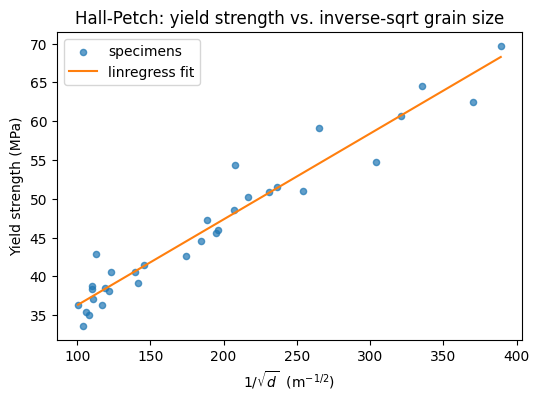

In [3]:
import matplotlib.pyplot as plt
from scipy import stats

res = stats.linregress(x, y)
print(f'slope (k)      = {res.slope:.4f} MPa*sqrt(m)   [literature: ~0.11 for annealed Cu]')
print(f'intercept (s0) = {res.intercept:.2f} MPa            [literature: ~25 for annealed Cu]')
print(f'R^2            = {res.rvalue**2:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=20, alpha=0.7, label='specimens')
xx = [x.min(), x.max()]
ax.plot(xx, [res.slope * xi + res.intercept for xi in xx], color='C1', label='linregress fit')
ax.set_xlabel(r'$1/\sqrt{d}$  (m$^{-1/2}$)')
ax.set_ylabel('Yield strength (MPa)')
ax.set_title('Hall-Petch: yield strength vs. inverse-sqrt grain size')
ax.legend()
plt.show()

R² north of 0.9, matching published constants for annealed copper. Keep that number as your
calibration point for a strong fit -- real data, coming up next, won't look like this, and
that's the lesson, not a flaw.

# Real data: proof stress and tensile strength

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [4]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


One housekeeping step before we plot anything. This dataset has a known data-entry problem:

In [5]:
print(data.loc[626, [' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)']])
print('next-highest Tensile Strength in the dataset:', data[' Tensile Strength (MPa)'].drop(index=626).max(), 'MPa')

0.2% Proof Stress (MPa)     519
Tensile Strength (MPa)     6661
Name: 626, dtype: object
next-highest Tensile Strength in the dataset: 830 MPa


6661 MPa is almost certainly a typo -- the next-highest tensile strength in all 915 alloys
is under 900 MPa. One impossible value like this can dominate a whole regression. Lecture 27
(Identifying Outliers) will teach you to catch things like this systematically; for today we
just eyeball-check it and drop the row.

In [6]:
data = data.drop(index=626)
x = data[' 0.2% Proof Stress (MPa)']
y = data[' Tensile Strength (MPa)']
print(f'{len(data)} alloys remaining')

914 alloys remaining


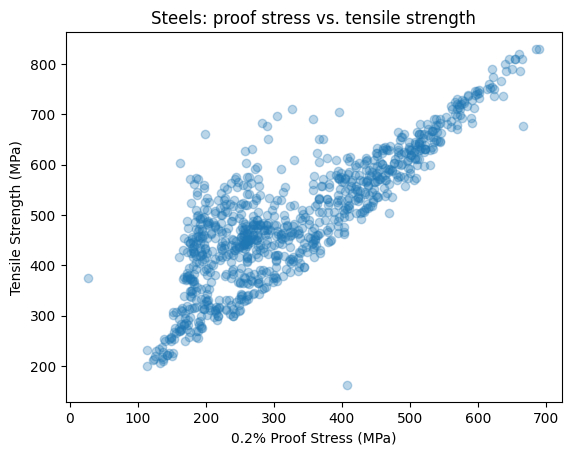

In [7]:
import matplotlib.pyplot as plt

plt.scatter(x, y, alpha=0.3)
plt.xlabel('0.2% Proof Stress (MPa)')
plt.ylabel('Tensile Strength (MPa)')
plt.title('Steels: proof stress vs. tensile strength')
plt.show()

If I told you a new alloy's proof stress, what's your best guess for its tensile strength? A
fitted line is a compressed way of answering exactly that.

# What makes a line "best"? Residuals and least squares

Any line `y_hat = m*x + b` is a candidate model. Here's a by-eye guess:

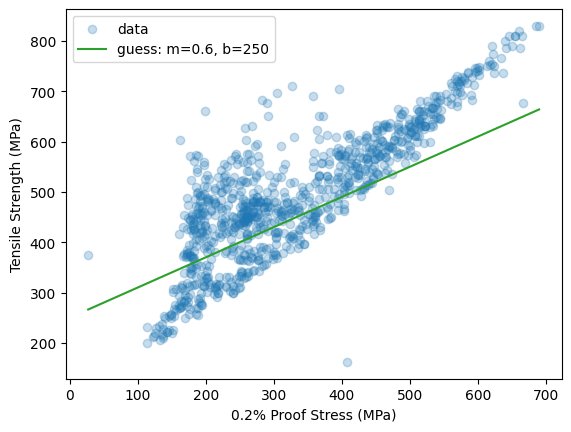

In [8]:
import numpy as np

xx = np.linspace(x.min(), x.max(), 200)

plt.scatter(x, y, alpha=0.25, label='data')
plt.plot(xx, 0.6 * xx + 250, color='C2', label='guess: m=0.6, b=250')
plt.xlabel('0.2% Proof Stress (MPa)'); plt.ylabel('Tensile Strength (MPa)')
plt.legend()
plt.show()

Plausible-looking, but "plausible" isn't a number. Define the **residual** for each point as
the vertical gap between the data and the line: `residual_i = y_i - y_hat_i`. Squaring the
residuals before adding them up is the standard move -- squaring penalizes big misses more
than small ones, and it keeps positive and negative residuals from cancelling out. That sum is
the **sum of squared errors (SSE)**:

In [9]:
def sse(m, b, x, y):
    y_hat = m * x + b
    return np.sum((y - y_hat) ** 2)

print(f'guess (m=0.6, b=250): SSE = {sse(0.6, 250, x, y):,.0f}')

guess (m=0.6, b=250): SSE = 6,615,309


That number is the guess's report card. **Least squares** means finding the `(m, b)` that
minimizes SSE over *every* possible line, not just the one we happened to try. We will not
derive the formula that finds that minimum by hand -- this is a curve-fitting course, not a
linear algebra course -- we'll let code find it.

# Fitting the line: `scipy.stats.linregress`

In [10]:
from scipy import stats

result = stats.linregress(x, y)
result.slope, result.intercept, result.rvalue

(np.float64(0.8021848385107052),
 np.float64(226.37875626876598),
 np.float64(0.8382778053459872))

`result` is an object with named fields -- the same pattern Lecture 15 previewed on this
exact pair. `np.polyfit(x, y, 1)` does the same job, returning slope and intercept as a plain
array instead:

In [11]:
slope, intercept = np.polyfit(x, y, 1)
print(f'np.polyfit: slope = {slope:.3f}, intercept = {intercept:.1f}')

np.polyfit: slope = 0.802, intercept = 226.4


Same numbers, two ways to ask for the same least-squares line. `linregress` also hands back
`.rvalue`, `.pvalue`, and `.stderr` in one call, which is why we standardize on it today.

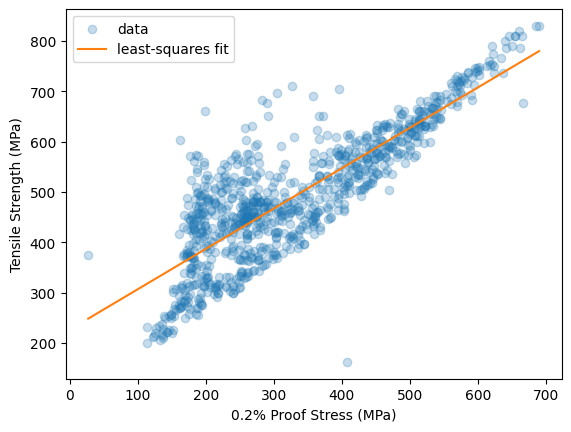

In [12]:
plt.scatter(x, y, alpha=0.25, label='data')
plt.plot(xx, result.slope * xx + result.intercept, color='C1', label='least-squares fit')
plt.xlabel('0.2% Proof Stress (MPa)'); plt.ylabel('Tensile Strength (MPa)')
plt.legend()
plt.show()

# Reading slope and intercept in physical units

Contrast: `F = 1.8*C + 32` is an *exact* definition -- no fitting, no residuals, no fit-
quality question. Our line is the opposite: an imperfect summary of scattered measurements,
which is exactly why "how good is this fit?" is meaningful for it and meaningless for the
temperature conversion.

Read off today's numbers (printed below): slope ≈ 0.80 MPa/MPa, intercept ≈ 226 MPa.
* **slope ≈ 0.80**: for every 1 MPa increase in proof stress, tensile strength increases by
  about 0.80 MPa on average. Slope < 1 means the gap between tensile strength and proof stress
  tends to *shrink* as alloys get stronger -- an observation, not a law.
* **intercept ≈ 226 MPa**: the model's predicted tensile strength at zero proof stress --
  **not physically meaningful**, since no real alloy has ~0 proof stress.

In [13]:
print(f'slope     = {result.slope:.3f} MPa/MPa')
print(f'intercept = {result.intercept:.1f} MPa')
print(f'observed proof stress range: {x.min():.0f}-{x.max():.0f} MPa')

slope     = 0.802 MPa/MPa
intercept = 226.4 MPa
observed proof stress range: 27-690 MPa


The intercept sits just outside the observed range -- a first, gentle lesson in not over-
interpreting a fit past the data it was built on. Turn the equation into a tool: predict
tensile strength for an alloy with 400 MPa proof stress, by hand first, then check it in code.

In [14]:
pred_400 = result.slope * 400 + result.intercept
print(f'predicted tensile strength at 400 MPa proof stress: {pred_400:.0f} MPa')

predicted tensile strength at 400 MPa proof stress: 547 MPa


# R² -- how much variation the line explains

> Residuals are the difference between a proposed model and the raw data values. For a
> least-squares line evaluated on the data it was fit to, the sum of residuals is zero, so we
> need to consider the variance instead.

R² = 1 - Var(residuals) / Var(data) is the fraction of the variance in `y` "explained" by the
line, ranging from 0 to 1. R² = 0.85 means the line accounts for 85% of why tensile strength
varies -- the other 15% is scatter it doesn't capture (composition, processing, microstructure
we haven't included).

In [15]:
r_squared = result.rvalue ** 2
print(f'R² = {r_squared:.3f}')

R² = 0.703


0.70 is a real, strong, positive relationship -- proof stress is genuinely the single best
linear predictor of tensile strength here -- but it is *not* the Hall-Petch line from the top
of class. 915 alloys carry composition and processing differences a single two-variable line
can't capture, exactly the scatter multivariate regression (Lecture 23) is built to handle.
And this 0.70 only looks this good *because* we dropped one bad row first -- before that
cleanup, the same fit reported R² ≈ 0.23. A model's R² is only as trustworthy as the data you
handed it.

R² is a spectrum, not a pass/fail flag -- the same one-liner works on a pair with almost no
linear relationship at all:

In [16]:
result_weak = stats.linregress(data[' C'], data[' Elongation (%)'])
print(f"carbon vs. elongation: R² = {result_weak.rvalue**2:.3f}")

carbon vs. elongation: R² = 0.022


Same one line of code, R² ≈ 0.02 instead of 0.70 -- carbon and elongation are essentially
unrelated here. R² measures fit quality, not whether you ran the code correctly.

One more caution: **correlation does not imply causation** -- two columns can move together
for reasons that have nothing to do with either one causing the other (see
tylervigen.com/spurious-correlations for absurd real examples).

## [Check your understanding]

Fit `' 0.2% Proof Stress (MPa)'` against `' Reduction in Area (%)'` on the (already cleaned)
`data`. Report the slope, intercept, and R², and write one sentence: is this a tight fit, a
modest one, or barely a relationship at all -- and how do you know, from the number alone?

# Wrap-up

* A model is a simplified stand-in for reality -- fit quality is meaningful for a model,
  meaningless for a definition.
* Fit -> compute residuals -> minimize SSE -> `linregress`/`np.polyfit` does the minimizing ->
  read slope/intercept in real units -> check R².
* An intercept far outside your data's range is an extrapolation, not a measurement.
* R² is a fraction of variance explained, not a pass/fail test -- only as trustworthy as the
  data you fit it on.

**Take-home message:** a fitted line is only as good as its R² says it is -- and never trust
its intercept, or its R², past the data you fit it on.

Next class: a train/test split, asking whether a fit that looks good on data it's already
seen holds up on the next alloy. HW7 Problems 1-3 apply today's pattern to new property pairs.